### StyleSense: Business Analytics
#### Answering 8 Business Questions from the Data

StyleSense is a growing clothing retailer selling through physical stores and online.
Leadership needs clear answers to act on. This notebook works through 8 business questions
drawn directly from the problems identified in the cleaning notebook.

Each question is labeled with the type of analysis it performs:

| Question | Business Question | Analysis Type |
|---|---|---|
| Q1 | Which products are the most profitable? | Descriptive |
| Q2 | Which customer segment spends the most? | Descriptive |
| Q3 | Do discounts actually increase sales? | Diagnostic |
| Q4 | How does each sales channel perform? | Descriptive + Diagnostic |
| Q5 | Is marketing spend generating returns? | Diagnostic + Prescriptive |
| Q6 | When should we restock seasonal products? | Predictive |
| Q7 | Which products are frequently out of stock? | Diagnostic + Prescriptive |
| Q8 | What is our true profit after all costs? | Descriptive + Prescriptive |

**The four analysis types used in this notebook:**
- **Descriptive:** What happened? Summarises what the data shows.
- **Diagnostic:** Why did it happen? Looks for causes and patterns behind the numbers.
- **Predictive:** What is likely to happen next? Uses historical patterns to forecast.
- **Prescriptive:** What should we do? Turns findings into clear recommendations.

In [1]:
# Library imports
import pandas as pd                    # data loading, grouping, and table operations
import numpy as np                     # numeric calculations
import matplotlib.pyplot as plt        # charts and visualisations
import matplotlib.ticker as mticker    # number formatting on chart axes
import matplotlib.patches as mpatches  # custom legend elements
import seaborn as sns                  # heatmaps and styled charts

# Chart styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

# Colour palette used consistently across all charts
BLUE   = "#1f77b4"
GREEN  = "#2ca02c"
ORANGE = "#ff7f0e"
RED    = "#d62728"
PURPLE = "#9467bd"
TEAL   = "#17becf"

In [2]:
# Load the feature-engineered datasets produced in the Feature Engineering notebook.
# These contain all the original cleaned columns plus new columns like
# margin_erosion, RFM_segment, is_near_stockout, days_until_stockout, and is_fixed_cost.
sales     = pd.read_csv('sales_featured.csv',     parse_dates=['date'])
customers = pd.read_csv('customers_featured.csv', parse_dates=['first_purchase_date', 'last_purchase_date'])
products  = pd.read_csv('products_featured.csv')
expenses  = pd.read_csv('expenses_featured.csv',  parse_dates=['date'])
inventory = pd.read_csv('inventory_featured.csv', parse_dates=['date'])

In [3]:
# Add a 'month' period column to sales, expenses, and inventory.
# dt.to_period('M') converts a date like 2024-03-15 into 2024-03 so we can group by month.
sales['month']     = sales['date'].dt.to_period('M')
expenses['month']  = expenses['date'].dt.to_period('M')
inventory['month'] = inventory['date'].dt.to_period('M')

In [4]:
print("Datasets loaded:")
print(f"  sales     : {sales.shape}")
print(f"  customers : {customers.shape}")
print(f"  products  : {products.shape}")
print(f"  expenses  : {expenses.shape}")
print(f"  inventory : {inventory.shape}")

Datasets loaded:
  sales     : (9989, 37)
  customers : (200, 24)
  products  : (25, 12)
  expenses  : (1322, 10)
  inventory : (13675, 17)


## Which Products Are the Most Profitable?
**Analysis type: Descriptive** (What happened?)

This question answers it at the product level by looking at total net profit earned
per product over 18 months, profit per unit sold, and the gap between the expected
catalogue margin and the margin actually achieved after discounts and returns.

The gap between catalogue margin and realised margin is called **margin erosion**.
A large gap means the product is being discounted heavily and real-world profit
is well below what the price list suggests.

In [5]:
# Group sales by product and calculate total profit, units, revenue, and margin metrics.
# catalogue_margin_pct and margin_erosion were added in the Feature Engineering notebook.
product_profit = sales.groupby('product_name').agg(
    total_net_profit     = ('net_profit',            'sum'),
    total_units_sold     = ('quantity_sold',          'sum'),
    total_revenue        = ('total_sale',             'sum'),
    transactions         = ('sale_id',                'count'),
    avg_realised_margin  = ('profit_margin_pct',      'mean'),
    avg_catalogue_margin = ('catalogue_margin_pct',   'mean'),
    avg_margin_erosion   = ('margin_erosion',         'mean')
).reset_index()

# Profit per unit: how much net profit does each unit sold generate on average
product_profit['avg_profit_per_unit'] = (product_profit['total_net_profit'] / product_profit['total_units_sold']).round(2)
product_profit['avg_realised_margin'] = product_profit['avg_realised_margin'].round(1)
product_profit['avg_margin_erosion']  = product_profit['avg_margin_erosion'].round(1)

# Sort by total net profit so the most profitable product appears first
product_profit = product_profit.sort_values('total_net_profit', ascending=False)

print("Top 10 Most Profitable Products:")
print(product_profit.head(10)[['product_name', 'total_net_profit', 'total_units_sold',
                                'avg_profit_per_unit', 'avg_realised_margin', 'avg_margin_erosion']].to_string(index=False))

Top 10 Most Profitable Products:
         product_name  total_net_profit  total_units_sold  avg_profit_per_unit  avg_realised_margin  avg_margin_erosion
  Men's Puffer Jacket          31885.20               661                48.24                 56.1                 5.0
Women's Puffer Jacket          30211.28               662                45.64                 56.8                 5.5
 Women's Skinny Jeans          24371.70               804                30.31                 57.9                 5.7
     Men's Slim Jeans          22316.97               803                27.79                 58.8                 5.2
 Women's Floral Dress          22182.88               726                30.55                 58.5                 5.1
         Men's Hoodie          22168.60               673                32.94                 58.3                 5.0
      Canvas Tote Bag          21880.35              1481                14.77                 63.0                 5.0
    Men

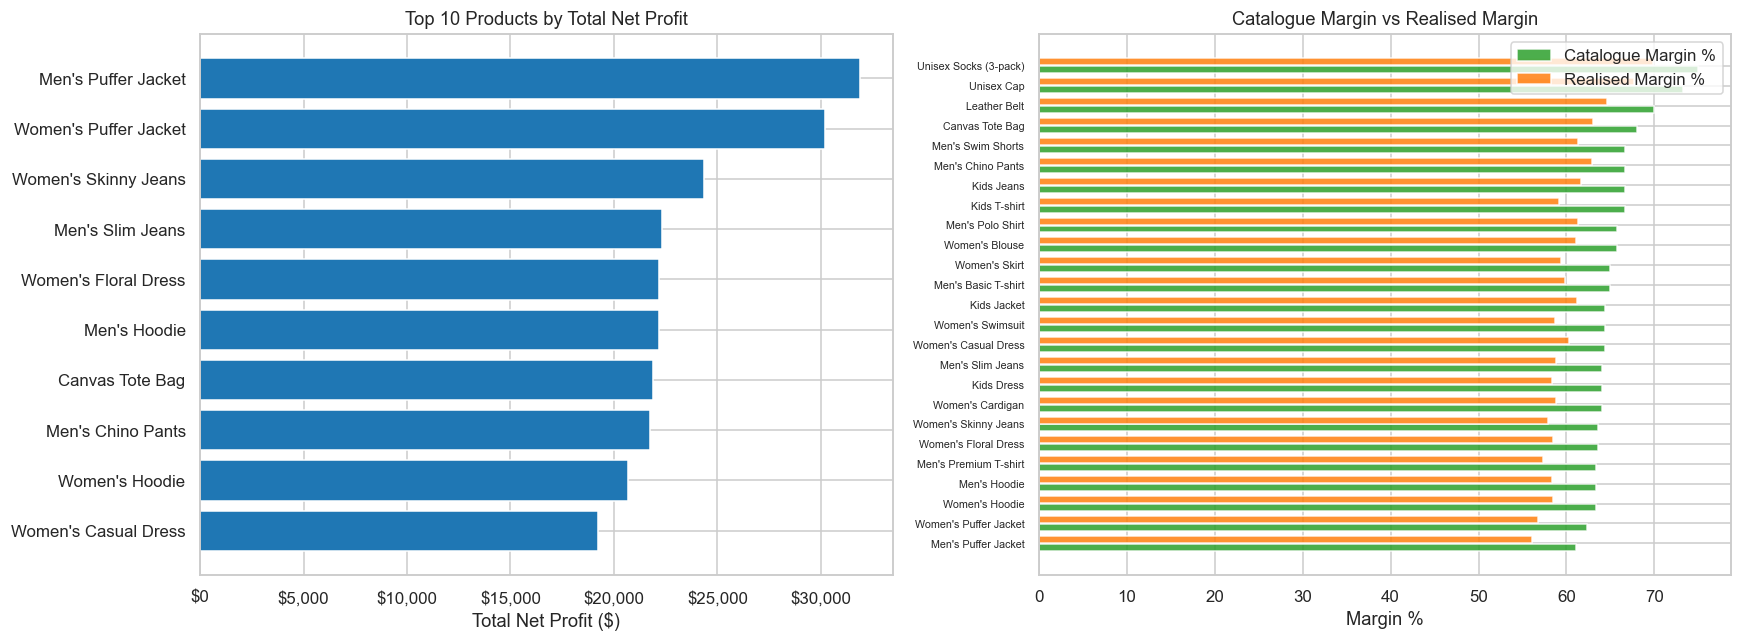

In [6]:
# Chart 1 (left): horizontal bar chart of the top 10 products by total net profit.
# Chart 2 (right): grouped bars comparing catalogue margin vs realised margin per product.
# The gap between green and orange bars is the margin erosion for each product.

top10 = product_profit.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left chart: top 10 products ranked by total net profit
axes[0].barh(top10['product_name'][::-1], top10['total_net_profit'][::-1], color=BLUE)
axes[0].set_xlabel("Total Net Profit ($)")
axes[0].set_title("Top 10 Products by Total Net Profit")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Right chart: all products with catalogue margin (green) vs realised margin (orange)
prod_sorted = product_profit.sort_values('avg_catalogue_margin')
positions   = range(len(prod_sorted))

axes[1].barh([i - 0.2 for i in positions], prod_sorted['avg_catalogue_margin'], 0.35,
             label='Catalogue Margin %', color=GREEN, alpha=0.85)
axes[1].barh([i + 0.2 for i in positions], prod_sorted['avg_realised_margin'], 0.35,
             label='Realised Margin %', color=ORANGE, alpha=0.85)
axes[1].set_yticks(list(positions))
axes[1].set_yticklabels(prod_sorted['product_name'], fontsize=7)
axes[1].set_title("Catalogue Margin vs Realised Margin")
axes[1].set_xlabel("Margin %")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Profit breakdown by product category.
# This shows whether Men, Women, Kids, or All-season products generate the most profit overall.
category_profit = sales.groupby('category').agg(
    total_net_profit = ('net_profit',  'sum'),
    total_revenue    = ('total_sale',  'sum')
).reset_index()

# Calculate the profit margin at the category level
category_profit['profit_margin_pct'] = (category_profit['total_net_profit'] / category_profit['total_revenue'] * 100).round(1)
category_profit = category_profit.sort_values('total_net_profit', ascending=False)

print("Profitability by Category:")
print(category_profit.to_string(index=False))

Profitability by Category:
category  total_net_profit  total_revenue  profit_margin_pct
   Women         179111.50      304622.14               58.8
     Men         140967.98      238494.33               59.1
     All          59522.76       91135.73               65.3
    Kids          15358.15       25160.44               61.0
   women           3462.81        5818.77               59.5
     men           2741.90        4375.89               62.7
     all           1381.08        2042.07               67.6
    kids            293.57         459.57               63.9


**Finding:** The products with the highest total net profit are not always the ones with the
highest margin percentage. A mid-margin product that sells in high volume can outperform
a high-margin product that sells slowly. The catalogue vs realised margin chart shows which
products are being over-discounted. A large gap between the two bars for a product means
discounting is eating into a significant portion of its theoretical profit.
These products are candidates for a tighter discount policy.


##  Which Customer Segment Spends the Most?
**Analysis type: Descriptive** (What happened?)

This question profiles spending across three lenses:
1. The CRM registration segment (Loyal, New, Seasonal, Occasional)
2. The behaviour-based segment built during data cleaning (Low, Mid, High Engagement)
3. The RFM segment built during feature engineering (Champion, Loyal, Potential, At Risk, Lost)

All three views of the same 200 customers are compared side by side.

In [8]:
# Average and total spend grouped by the CRM registration segment.
# This is the segment label that came with the raw customer data.
seg_spend = customers.groupby('segment').agg(
    customer_count = ('customer_id', 'count'),
    avg_spent      = ('total_spent',  'mean'),
    total_spent    = ('total_spent',  'sum'),
    avg_orders     = ('num_orders',   'mean')
).reset_index()

seg_spend['avg_spent']  = seg_spend['avg_spent'].round(2)
seg_spend['avg_orders'] = seg_spend['avg_orders'].round(1)
seg_spend = seg_spend.sort_values('avg_spent', ascending=False)

print("Spending by CRM Segment:")
print(seg_spend.to_string(index=False))

Spending by CRM Segment:
       segment  customer_count  avg_spent  total_spent  avg_orders
         Loyal              36    4669.46    168100.54        51.0
Bargain Hunter              18    4647.88     83661.76        49.0
    Occasional              55    2988.80    164384.17        50.7
      Seasonal              35    2826.54     98929.03        50.9
           New              56    2804.13    157031.26        48.2


In [9]:
# Average and total spend grouped by the behaviour-based derived_segment.
# This segment was built during data cleaning based on how many orders each customer placed.
# Low Engagement: fewer than 35 orders, Mid: 35 to 54, High: 55 or more.
derived_spend = customers.groupby('derived_segment').agg(
    customer_count = ('customer_id', 'count'),
    avg_spent      = ('total_spent',  'mean'),
    total_spent    = ('total_spent',  'sum'),
    avg_orders     = ('num_orders',   'mean')
).reset_index()

derived_spend['avg_spent']  = derived_spend['avg_spent'].round(2)
derived_spend['avg_orders'] = derived_spend['avg_orders'].round(1)
derived_spend = derived_spend.sort_values('avg_spent', ascending=False)

print("Spending by Behaviour-Based Segment:")
print(derived_spend.to_string(index=False))

Spending by Behaviour-Based Segment:
derived_segment  customer_count  avg_spent  total_spent  avg_orders
High Engagement              47    3960.22    186130.51        60.0
 Mid Engagement             151    3195.45    482512.22        47.1
 Low Engagement               2    1732.02      3464.03        31.0


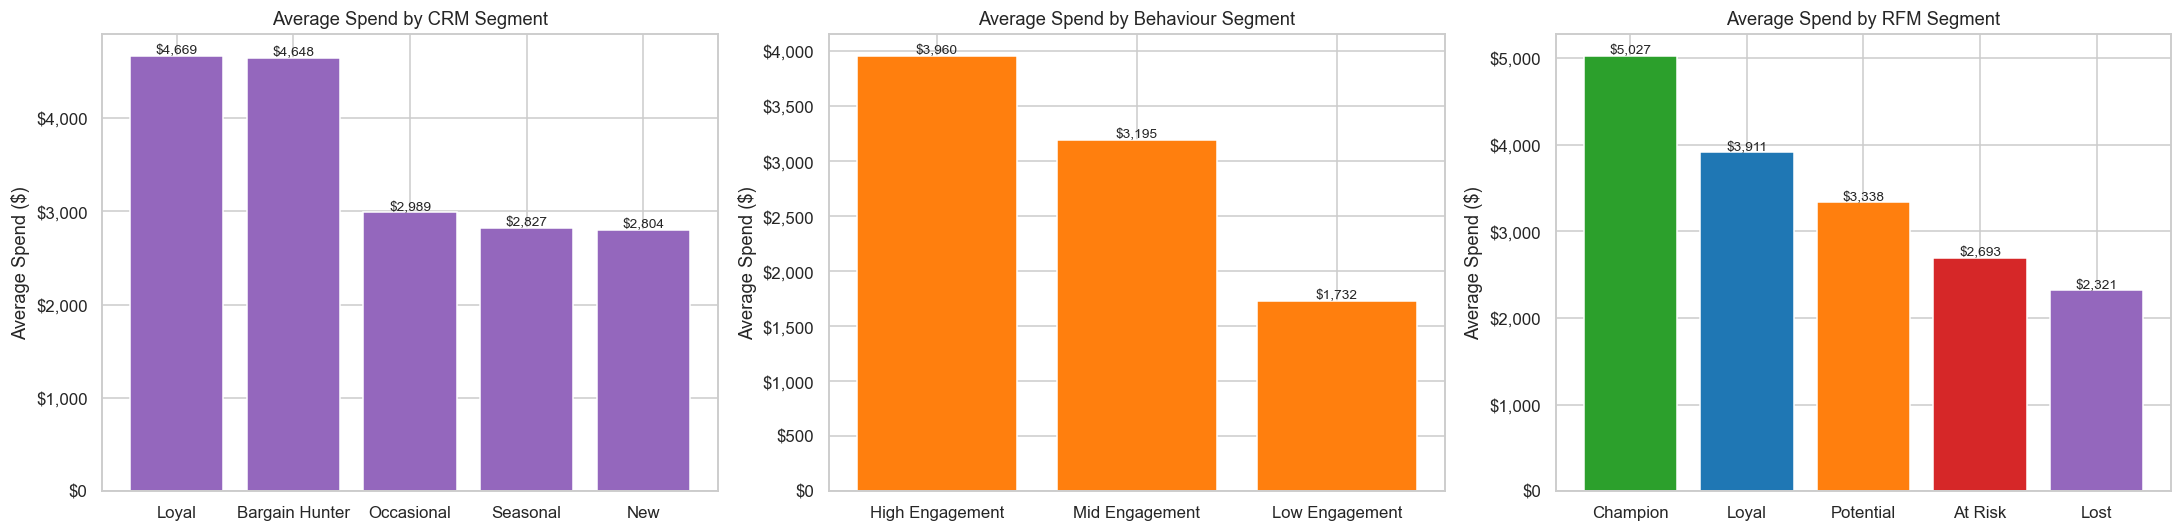

In [10]:
# Three bar charts side by side: CRM segment, behaviour segment, and RFM segment.
# Each shows average spend so the bars are comparable regardless of group size.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Left chart: average spend by CRM registration segment
axes[0].bar(seg_spend['segment'], seg_spend['avg_spent'], color=PURPLE)
axes[0].set_title("Average Spend by CRM Segment")
axes[0].set_ylabel("Average Spend ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(axes[0].patches, seg_spend['avg_spent']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"${val:,.0f}", ha='center', fontsize=9)

# Centre chart: average spend by behaviour-based segment
axes[1].bar(derived_spend['derived_segment'], derived_spend['avg_spent'], color=ORANGE)
axes[1].set_title("Average Spend by Behaviour Segment")
axes[1].set_ylabel("Average Spend ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(axes[1].patches, derived_spend['avg_spent']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"${val:,.0f}", ha='center', fontsize=9)

# Right chart: average spend by RFM segment (built in Feature Engineering)
rfm_spend = customers.groupby('RFM_segment').agg(
    customer_count = ('customer_id', 'count'),
    avg_spent      = ('total_spent',  'mean')
).reset_index()

# Order the RFM segments from highest to lowest value
seg_order = ['Champion', 'Loyal', 'Potential', 'At Risk', 'Lost']
rfm_spend['RFM_segment'] = pd.Categorical(rfm_spend['RFM_segment'], categories=seg_order, ordered=True)
rfm_spend = rfm_spend.sort_values('RFM_segment')

colors_rfm = [GREEN, BLUE, ORANGE, RED, PURPLE]
axes[2].bar(rfm_spend['RFM_segment'], rfm_spend['avg_spent'], color=colors_rfm)
axes[2].set_title("Average Spend by RFM Segment")
axes[2].set_ylabel("Average Spend ($)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(axes[2].patches, rfm_spend['avg_spent']):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"${val:,.0f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Which product categories does each CRM segment prefer?
# This tells marketing which products to feature in campaigns for each group.
seg_fav = customers.groupby(['segment', 'favourite_category']).size().reset_index(name='count')
seg_fav = seg_fav.sort_values(['segment', 'count'], ascending=[True, False])
top_fav = seg_fav.groupby('segment').head(3)

print("Top 3 Favourite Categories per CRM Segment:")
print(top_fav.to_string(index=False))

Top 3 Favourite Categories per CRM Segment:
       segment favourite_category  count
Bargain Hunter              Women     10
Bargain Hunter                Men      8
         Loyal                Men     21
         Loyal              Women     15
           New              Women     37
           New                Men     18
           New                All      1
    Occasional              Women     27
    Occasional                Men     25
    Occasional                All      3
      Seasonal                Men     19
      Seasonal              Women     16


In [12]:
# Identify the top At Risk customers by total spend.
# These are customers who were high-value but have not purchased recently.
# This list is the starting point for a targeted win-back campaign.
at_risk_customers = customers[customers['RFM_segment'] == 'At Risk'].copy()
at_risk_customers = at_risk_customers.sort_values('total_spent', ascending=False)

print("Top 10 At Risk Customers by Total Spend (win-back priority list):")
print(at_risk_customers[['customer_id', 'total_spent', 'num_orders',
                           'recency_days', 'favourite_category']].head(10).to_string(index=False))

Top 10 At Risk Customers by Total Spend (win-back priority list):
customer_id  total_spent  num_orders  recency_days favourite_category
       C053      4396.63          43            26              Women
       C174      3912.64          47            30                Men
       C063      3528.49          39            30                Men
       C192      3474.68          47            30              Women
       C166      3410.99          46            28              Women
       C041      3232.88          47            20              Women
       C015      3209.94          40            12              Women
       C097      3107.70          46            13              Women
       C104      3079.52          43            15              Women
       C060      3030.23          48            26              Women


**Finding:** Loyal customers drive the highest lifetime value based on total spend.
The behaviour-based segment confirms that High Engagement customers, regardless of their
CRM label, are the most valuable group. The RFM segment adds a retention dimension.
Champions are recent buyers, frequent purchasers, and high spenders. They need to be protected
with loyalty rewards and early product access. At Risk customers have a strong purchase history
but have not bought recently. The win-back list above shows exactly which customers to contact
first, prioritized by how much they have spent historically.


## Do Discounts Actually Increase Sales?
**Analysis type: Diagnostic** (Why did it happen?)

This question compares five discount tiers (0%, 5%, 10%, 15%, 20%)
across transaction volume, average revenue, profit margin, return rate, and margin erosion.

Margin erosion is the number of margin percentage points lost compared to the catalogue price.
It is a direct measure of the cost of discounting.

In [13]:
# Group transactions by discount tier.
# For each tier we want to know: how many transactions, how much revenue,
# what was the profit margin, how often were items returned, and how much margin was eroded.
discount_analysis = sales.groupby('discount_pct').agg(
    transactions       = ('sale_id',          'count'),
    avg_units_sold     = ('quantity_sold',     'mean'),
    total_units_sold   = ('quantity_sold',     'sum'),
    total_revenue      = ('total_sale',        'sum'),
    total_net_profit   = ('net_profit',        'sum'),
    return_rate        = ('is_returned',       'mean'),
    avg_margin_erosion = ('margin_erosion',    'mean')
).reset_index()

# Calculate derived metrics per tier
discount_analysis['avg_revenue_per_tx'] = (discount_analysis['total_revenue']    / discount_analysis['transactions']).round(2)
discount_analysis['avg_profit_per_tx']  = (discount_analysis['total_net_profit'] / discount_analysis['transactions']).round(2)
discount_analysis['profit_margin_pct']  = (discount_analysis['total_net_profit'] / discount_analysis['total_revenue'] * 100).round(1)
discount_analysis['return_rate']        = (discount_analysis['return_rate'] * 100).round(1)
discount_analysis['avg_margin_erosion'] = discount_analysis['avg_margin_erosion'].round(1)

print("Discount Tier Summary:")
print(discount_analysis[['discount_pct', 'transactions', 'avg_units_sold', 'avg_revenue_per_tx',
                          'avg_profit_per_tx', 'profit_margin_pct', 'return_rate',
                          'avg_margin_erosion']].to_string(index=False))

Discount Tier Summary:
 discount_pct  transactions  avg_units_sold  avg_revenue_per_tx  avg_profit_per_tx  profit_margin_pct  return_rate  avg_margin_erosion
            0          4489        1.811985               68.51              42.31               61.8          5.1                 3.4
            5          2189        1.870260               67.15              40.48               60.3          4.6                 4.7
           10          1829        1.926189               67.55              39.47               58.4          4.6                 6.6
           15          1127        1.924579               63.08              35.22               55.8          5.1                 9.0
           20           355        2.123944               64.64              34.96               54.1          4.2                10.9


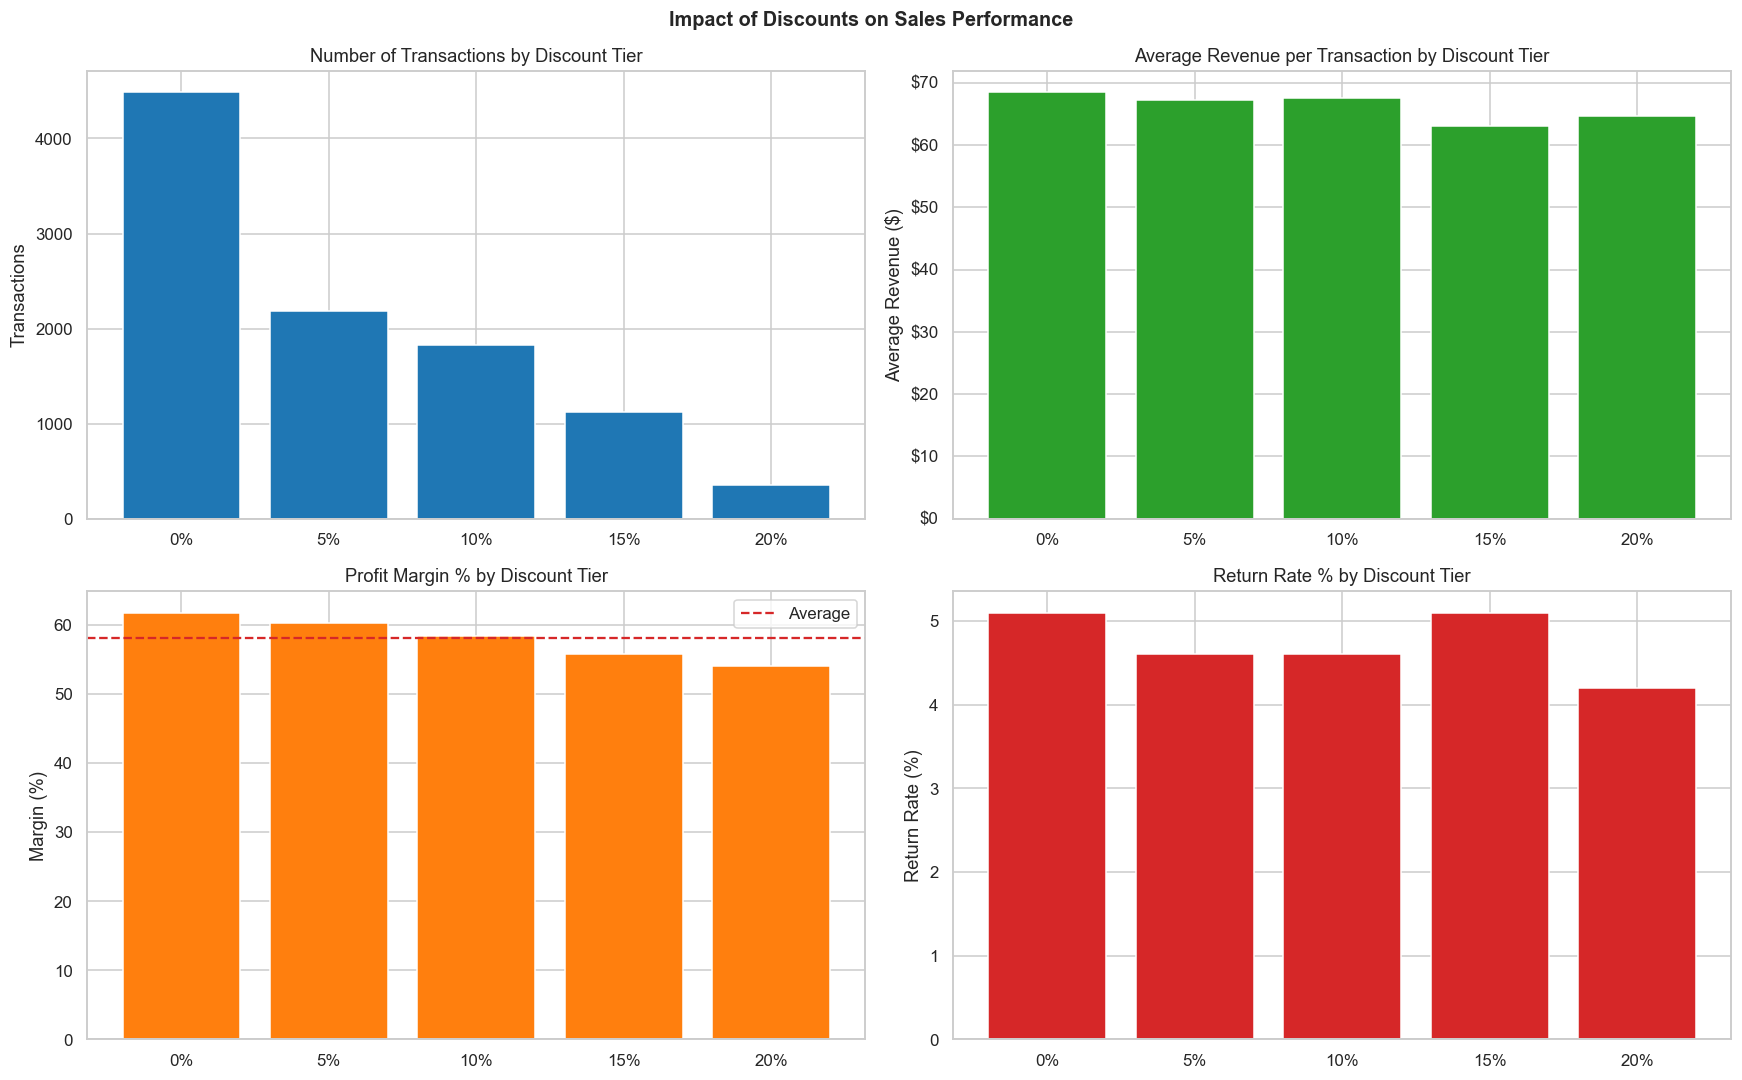

In [14]:
# Four charts showing the effect of each discount tier on key performance metrics.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Create a label like "0%", "5%", etc. for the x-axis
x = discount_analysis['discount_pct'].astype(str) + '%'

# Chart 1: how many transactions occurred at each discount level
axes[0, 0].bar(x, discount_analysis['transactions'], color=BLUE)
axes[0, 0].set_title("Number of Transactions by Discount Tier")
axes[0, 0].set_ylabel("Transactions")

# Chart 2: average revenue earned per transaction at each tier
axes[0, 1].bar(x, discount_analysis['avg_revenue_per_tx'], color=GREEN)
axes[0, 1].set_title("Average Revenue per Transaction by Discount Tier")
axes[0, 1].set_ylabel("Average Revenue ($)")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Chart 3: profit margin percentage at each tier with an average reference line
axes[1, 0].bar(x, discount_analysis['profit_margin_pct'], color=ORANGE)
axes[1, 0].set_title("Profit Margin % by Discount Tier")
axes[1, 0].set_ylabel("Margin (%)")
axes[1, 0].axhline(discount_analysis['profit_margin_pct'].mean(), color=RED,
                    linestyle='--', label='Average')
axes[1, 0].legend()

# Chart 4: percentage of transactions that were returned at each tier
axes[1, 1].bar(x, discount_analysis['return_rate'], color=RED)
axes[1, 1].set_title("Return Rate % by Discount Tier")
axes[1, 1].set_ylabel("Return Rate (%)")

plt.suptitle("Impact of Discounts on Sales Performance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** If transaction volume rises at higher discount tiers but profit margin falls,
discounts are growing top-line revenue at the cost of profitability. If return rates are
higher for discounted items, that further reduces net profit because returned transactions
record zero net profit. The avg_margin_erosion column in the summary table shows exactly
how many margin points are lost at each tier. If a 20% discount erodes 20 or more margin
points without a matching jump in transaction volume, that tier is destroying more value
than it creates. The data shows whether StyleSense's discount strategy is generating
real profit or just moving units at a loss.

##  How Does Each Sales Channel Perform?
**Analysis type: Descriptive + Diagnostic** (What happened? + Why?)

This question compares
revenue, profit, order size, return rate, discount usage, and margin erosion for each channel.
Margin erosion from feature engineering adds a new dimension: it shows whether one channel
is structurally more discount-driven than the other.

In [15]:
# Compare the two sales channels across all key performance metrics.
channel = sales.groupby('store_channel').agg(
    transactions       = ('sale_id',          'count'),
    total_revenue      = ('total_sale',        'sum'),
    total_net_profit   = ('net_profit',        'sum'),
    avg_order_value    = ('total_sale',        'mean'),
    avg_discount_pct   = ('discount_pct',      'mean'),
    return_rate        = ('is_returned',       'mean'),
    avg_units_sold     = ('quantity_sold',     'mean'),
    avg_margin_erosion = ('margin_erosion',    'mean')
).reset_index()

# Calculate profit margin at the channel level
channel['profit_margin_pct']  = (channel['total_net_profit'] / channel['total_revenue'] * 100).round(1)
channel['return_rate']        = (channel['return_rate'] * 100).round(1)
channel['avg_order_value']    = channel['avg_order_value'].round(2)
channel['avg_discount_pct']   = channel['avg_discount_pct'].round(1)
channel['avg_margin_erosion'] = channel['avg_margin_erosion'].round(1)

print("Channel Performance Summary:")
print(channel.to_string(index=False))

Channel Performance Summary:
store_channel  transactions  total_revenue  total_net_profit  avg_order_value  avg_discount_pct  return_rate  avg_units_sold  avg_margin_erosion  profit_margin_pct
       Online          4547      310378.98         185226.35            68.26               5.3          5.2        1.878821                 5.4               59.7
     Physical          5442      361729.96         217613.40            66.47               5.3          4.5        1.861632                 5.0               60.2


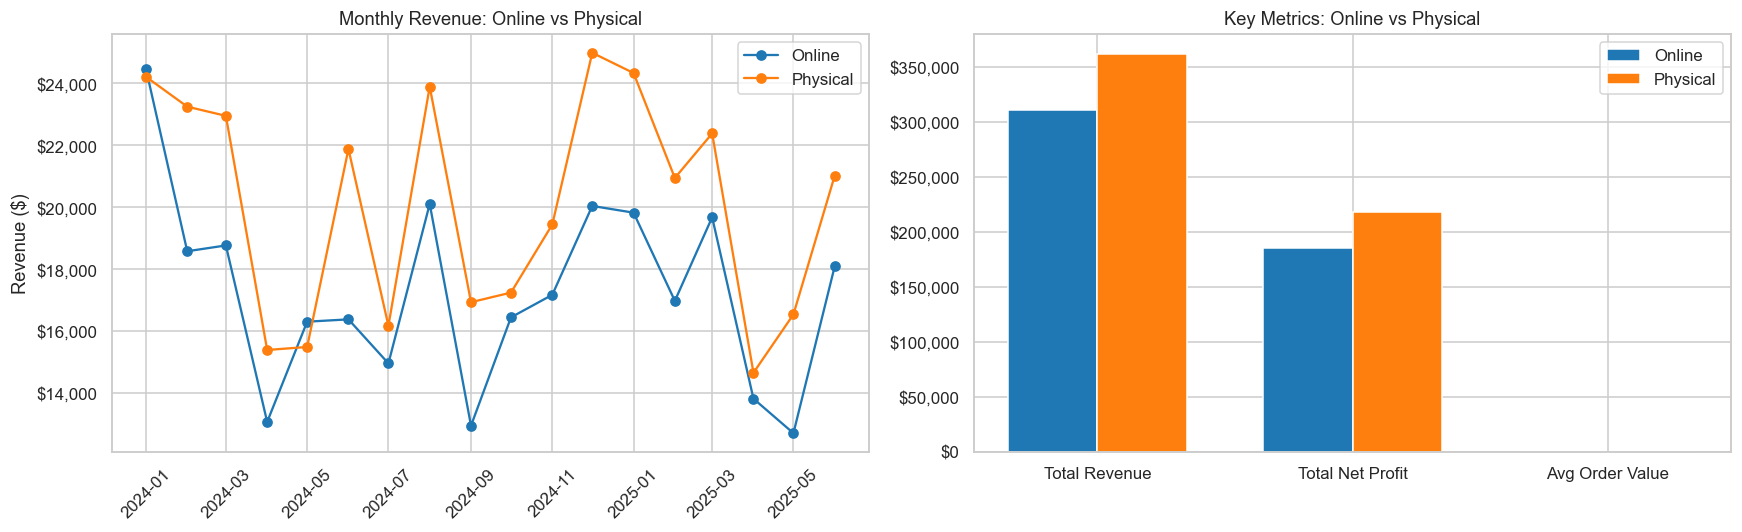

In [16]:
# Left chart: monthly revenue trend for each channel over 18 months.
# Right chart: side-by-side bar comparison of revenue, profit, and average order value.
monthly_channel = sales.groupby(['month', 'store_channel'])['total_sale'].sum().reset_index()
monthly_channel['month_dt'] = monthly_channel['month'].dt.to_timestamp()

online   = monthly_channel[monthly_channel['store_channel'] == 'Online']
physical = monthly_channel[monthly_channel['store_channel'] == 'Physical']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left chart: monthly revenue trend
axes[0].plot(online['month_dt'],   online['total_sale'],   label='Online',   color=BLUE,   marker='o')
axes[0].plot(physical['month_dt'], physical['total_sale'], label='Physical', color=ORANGE, marker='o')
axes[0].set_title("Monthly Revenue: Online vs Physical")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Right chart: grouped bars for total revenue, total net profit, and average order value
metrics       = ['total_revenue', 'total_net_profit', 'avg_order_value']
labels        = ['Total Revenue', 'Total Net Profit', 'Avg Order Value']
positions     = range(len(metrics))
bar_width     = 0.35
online_vals   = [channel[channel['store_channel'] == 'Online'][m].values[0]   for m in metrics]
physical_vals = [channel[channel['store_channel'] == 'Physical'][m].values[0] for m in metrics]

axes[1].bar([i - bar_width / 2 for i in positions], online_vals,   bar_width, label='Online',   color=BLUE)
axes[1].bar([i + bar_width / 2 for i in positions], physical_vals, bar_width, label='Physical', color=ORANGE)
axes[1].set_xticks(list(positions))
axes[1].set_xticklabels(labels)
axes[1].set_title("Key Metrics: Online vs Physical")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# Payment method breakdown by channel.
# This shows whether online and physical customers pay differently,
# which can be useful when evaluating payment processing costs.
payment_channel = sales.groupby(['store_channel', 'payment_method']).size().reset_index(name='count')
payment_pct     = payment_channel.copy()
totals          = payment_pct.groupby('store_channel')['count'].transform('sum')
payment_pct['pct'] = (payment_pct['count'] / totals * 100).round(1)

print("Payment Method Split by Channel (%):")
print(payment_pct.to_string(index=False))

Payment Method Split by Channel (%):
store_channel payment_method  count  pct
       Online    Credit Card   2033 44.7
       Online     Debit Card    949 20.9
       Online     Mobile Pay    857 18.8
       Online         PayPal    707 15.5
       Online        Unknown      1  0.0
     Physical           Cash   1104 20.3
     Physical    Credit Card   2148 39.5
     Physical     Debit Card   1389 25.5
     Physical     Mobile Pay    797 14.6
     Physical        Unknown      4  0.1


**Finding:** If one channel has a higher return rate, it signals a customer experience
problem or a mismatch between what customers expect and what they receive. If online has
a higher average order value but a lower profit margin, fulfilment or shipping costs may
be reducing profit on online orders. The avg_margin_erosion figure shows whether one
channel is more discount-driven. A higher erosion value means that channel's customers
are purchasing more heavily on discount, which reduces the realised margin relative to
the catalogue price. The monthly trend shows whether either channel is growing or
declining across the 18-month window.


## Is Marketing Spend Generating Returns?
**Analysis type: Diagnostic + Prescriptive** (Why? + What to do?)

This question isolates marketing spend from the expenses
dataset and calculates Return on Marketing Spend (ROMS) per month.

ROMS measures how much revenue is generated for every dollar spent on marketing.
A ROMS of 10 means 10 dollars of revenue for every 1 dollar of marketing spend.
Profit ROMS measures the same thing using net profit instead of revenue.
If profit ROMS is falling while revenue ROMS holds steady, marketing is driving
sales at increasingly thin margins.

In [18]:
# Isolate monthly marketing spend from the expenses dataset
marketing_expenses = expenses[expenses['category'] == 'Marketing'].copy()
monthly_marketing  = marketing_expenses.groupby('month')['amount'].sum().reset_index()
monthly_marketing.columns = ['month', 'marketing_spend']

# Monthly revenue from sales
monthly_revenue = sales.groupby('month')['total_sale'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']

# Monthly net profit from sales
monthly_profit = sales.groupby('month')['net_profit'].sum().reset_index()
monthly_profit.columns = ['month', 'net_profit']

# Combine all three into one table
mkt = monthly_marketing.merge(monthly_revenue, on='month', how='inner')
mkt = mkt.merge(monthly_profit, on='month', how='inner')

# ROMS: how much revenue is earned per dollar of marketing spend
mkt['roms'] = (mkt['revenue'] / mkt['marketing_spend']).round(2)

# Profit ROMS: how much net profit is earned per dollar of marketing spend
mkt['profit_roms'] = (mkt['net_profit'] / mkt['marketing_spend']).round(2)

mkt['month_dt'] = mkt['month'].dt.to_timestamp()

print("Monthly Marketing Spend vs Revenue:")
print(mkt[['month', 'marketing_spend', 'revenue', 'net_profit', 'roms', 'profit_roms']].to_string(index=False))

Monthly Marketing Spend vs Revenue:
  month  marketing_spend  revenue  net_profit  roms  profit_roms
2024-01          1110.42 48676.10    28985.17 43.84        26.10
2024-02           914.09 41826.37    24669.08 45.76        26.99
2024-03           786.96 41717.20    24755.96 53.01        31.46
2024-04           658.12 28469.56    17164.76 43.26        26.08
2024-05           401.81 31800.97    19374.95 79.14        48.22
2024-06           988.81 38262.66    23073.06 38.70        23.33
2024-07           767.38 31139.84    19007.75 40.58        24.77
2024-08          1064.86 43995.76    26106.18 41.32        24.52
2024-09           831.30 29888.35    18165.56 35.95        21.85
2024-10           390.80 33694.93    20440.62 86.22        52.30
2024-11           569.80 36618.58    21518.62 64.27        37.77
2024-12          1766.78 45025.71    26594.43 25.48        15.05
2025-01           506.40 44155.95    26619.35 87.20        52.57
2025-02          1328.67 37925.25    22951.92 28.54   

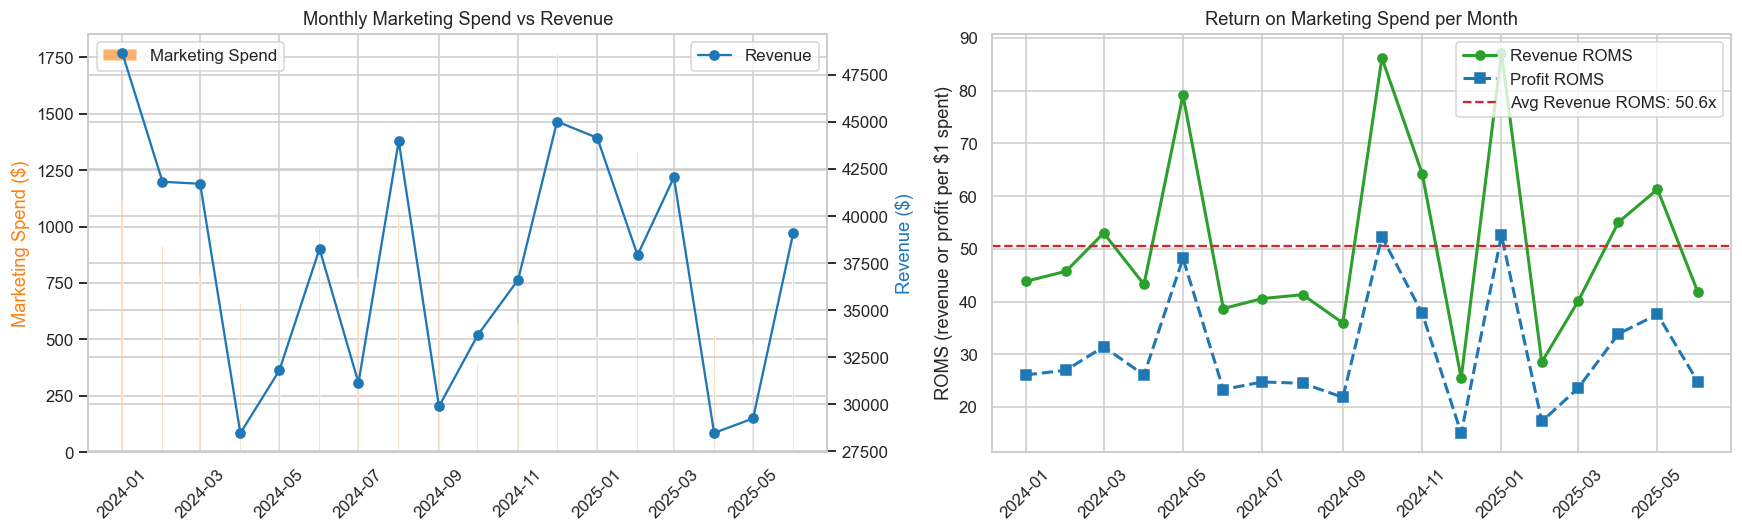

In [19]:
# Left chart: marketing spend as bars with revenue as a line (dual axis).
# Right chart: both ROMS metrics over time so we can see if they diverge.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left chart: bars for spend, line for revenue on a second y-axis
ax2 = axes[0].twinx()
axes[0].bar(mkt['month_dt'], mkt['marketing_spend'], color=ORANGE, alpha=0.6, label='Marketing Spend')
ax2.plot(mkt['month_dt'], mkt['revenue'], color=BLUE, marker='o', label='Revenue')
axes[0].set_title("Monthly Marketing Spend vs Revenue")
axes[0].set_ylabel("Marketing Spend ($)", color=ORANGE)
ax2.set_ylabel("Revenue ($)", color=BLUE)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Right chart: revenue ROMS and profit ROMS with an average reference line
axes[1].plot(mkt['month_dt'], mkt['roms'],        color=GREEN,  marker='o', linewidth=2, label='Revenue ROMS')
axes[1].plot(mkt['month_dt'], mkt['profit_roms'], color=BLUE,   marker='s', linewidth=2, linestyle='--', label='Profit ROMS')
axes[1].axhline(mkt['roms'].mean(), color=RED, linestyle='--',
                label=f"Avg Revenue ROMS: {mkt['roms'].mean():.1f}x")
axes[1].set_title("Return on Marketing Spend per Month")
axes[1].set_ylabel("ROMS (revenue or profit per $1 spent)")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# Compare promotional transactions vs non-promotional transactions.
# is_promotion = True means the sale happened during a promotional period.
# We want to know whether promotions lead to better results or just cannibalise margin.
promo = sales.groupby('is_promotion').agg(
    transactions    = ('sale_id',        'count'),
    avg_order_value = ('total_sale',     'mean'),
    avg_net_profit  = ('net_profit',     'mean'),
    avg_units_sold  = ('quantity_sold',  'mean'),
    return_rate     = ('is_returned',    'mean')
).reset_index()

promo['return_rate']     = (promo['return_rate'] * 100).round(1)
promo['avg_order_value'] = promo['avg_order_value'].round(2)
promo['avg_net_profit']  = promo['avg_net_profit'].round(2)
promo['label']           = promo['is_promotion'].map({True: 'Promotion', False: 'No Promotion'})

print("Promotional vs Non-Promotional Transactions:")
print(promo[['label', 'transactions', 'avg_order_value', 'avg_net_profit',
             'avg_units_sold', 'return_rate']].to_string(index=False))

Promotional vs Non-Promotional Transactions:
       label  transactions  avg_order_value  avg_net_profit  avg_units_sold  return_rate
No Promotion          7306            68.11           41.32        1.865864          4.9
   Promotion          2683            65.03           37.63        1.879240          4.7


**Finding:** If ROMS is declining over time, marketing spend is becoming less efficient.
If profit ROMS is falling while revenue ROMS stays flat, marketing is driving more sales
but at thinner margins. This means promotions are attracting price-sensitive buyers who
discount the product value. If promotional transactions also show a lower average net
profit than non-promotional ones, promotions are cutting into margin without adding
enough volume to compensate. StyleSense should direct its marketing budget toward
months with historically high ROMS and reduce broad promotions on products that
already sell well without a discount.

## When Should We Restock Seasonal Products?
**Analysis type: Predictive** (What is likely to happen next?)

This question uses 18 months of inventory
data to identify the exact months when seasonal stock levels drop fastest and when
near-stockout events are most concentrated.

The days_until_stockout column from feature engineering gives a forward-looking estimate:
how many days of stock remain at the current sales pace. Any product with fewer than 21 days
remaining during a high-demand month needs a reorder placed immediately, assuming a
standard 3-week supplier lead time.

In [21]:
# Merge inventory data with the products table to get the season tag for each product.
# The inventory table records daily stock levels but does not store the season.
inv_products = inventory.merge(products[['product_id', 'season']], on='product_id', how='left')

# Filter to seasonal products only
winter_inv = inv_products[inv_products['season'].isin(['Winter', 'All'])]
summer_inv = inv_products[inv_products['season'].isin(['Summer', 'All'])]

print("Winter products:", inv_products[inv_products['season'] == 'Winter']['product_name'].unique())
print("Summer products:", inv_products[inv_products['season'] == 'Summer']['product_name'].unique())

Winter products: <StringArray>
[         'Men's Hoodie',   'Men's Puffer Jacket',        'Women's Hoodie',
 'Women's Puffer Jacket',      'Women's Cardigan',           'Kids Jacket']
Length: 6, dtype: str
Summer products: <StringArray>
[    'Men's Polo Shirt', 'Women's Floral Dress',        'Women's Skirt',
           'Kids Dress',    'Men's Swim Shorts',     'Women's Swimsuit']
Length: 6, dtype: str


In [24]:
# Calculate average stock level for each calendar month.
# We derive month_num directly from the date column to ensure it is always present,
# even if it was not carried through the merge in the previous cell.
inv_products['month_num'] = inv_products['date'].dt.month

# Re-filter the seasonal subsets now that month_num is on inv_products
winter_inv = inv_products[inv_products['season'].isin(['Winter', 'All'])]
summer_inv = inv_products[inv_products['season'].isin(['Summer', 'All'])]

# Group by month number and calculate the mean stock level for each month
winter_monthly = winter_inv[winter_inv['season'] == 'Winter'].groupby('month_num')['stock_level'].mean().reset_index()
summer_monthly = summer_inv[summer_inv['season'] == 'Summer'].groupby('month_num')['stock_level'].mean().reset_index()

# Convert month number to a readable three-letter name (1 becomes Jan, etc.)
winter_monthly['month_name'] = pd.to_datetime(winter_monthly['month_num'], format='%m').dt.strftime('%b')
summer_monthly['month_name'] = pd.to_datetime(summer_monthly['month_num'], format='%m').dt.strftime('%b')

print('Average stock level by month for Winter products:')
print(winter_monthly[['month_name', 'stock_level']].to_string(index=False))
print()
print('Average stock level by month for Summer products:')
print(summer_monthly[['month_name', 'stock_level']].to_string(index=False))

Average stock level by month for Winter products:
month_name  stock_level
       Jan   131.462366
       Feb   105.500000
       Mar   112.602151
       Apr   107.908333
       May    98.438172
       Jun    91.300000
       Jul    97.403226
       Aug   100.489247
       Sep    92.777778
       Oct   104.059140
       Nov   103.361111
       Dec    95.193548

Average stock level by month for Summer products:
month_name  stock_level
       Jan   139.793011
       Feb   135.979532
       Mar   134.943548
       Apr   103.147222
       May    96.435484
       Jun   104.383333
       Jul   106.612903
       Aug    93.451613
       Sep    95.150000
       Oct    79.516129
       Nov    77.761111
       Dec    82.419355


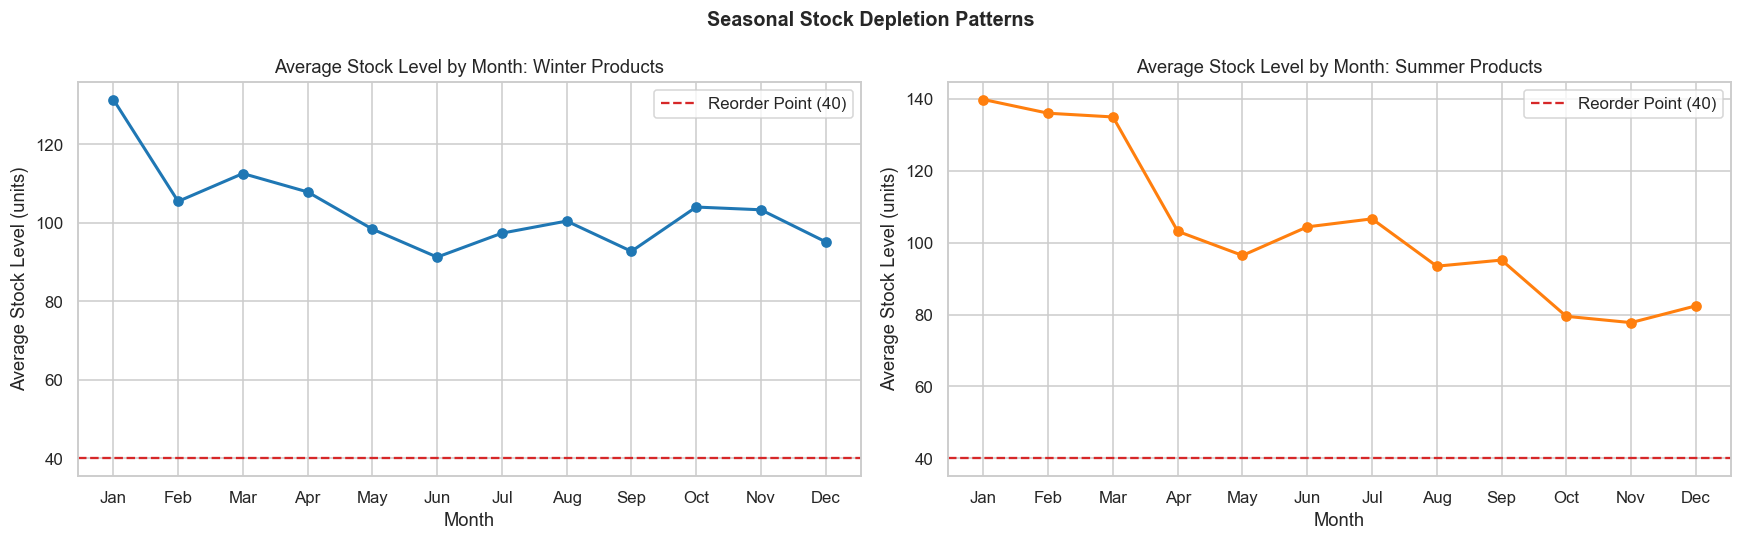

In [25]:
# Two line charts showing how average stock level changes across the year
# for winter products (left) and summer products (right).
# The red dashed line marks the reorder point at 40 units.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(winter_monthly['month_name'], winter_monthly['stock_level'],
             marker='o', color=BLUE, linewidth=2)
axes[0].set_title("Average Stock Level by Month: Winter Products")
axes[0].set_ylabel("Average Stock Level (units)")
axes[0].set_xlabel("Month")
axes[0].axhline(40, color=RED, linestyle='--', label='Reorder Point (40)')
axes[0].legend()

axes[1].plot(summer_monthly['month_name'], summer_monthly['stock_level'],
             marker='o', color=ORANGE, linewidth=2)
axes[1].set_title("Average Stock Level by Month: Summer Products")
axes[1].set_ylabel("Average Stock Level (units)")
axes[1].set_xlabel("Month")
axes[1].axhline(40, color=RED, linestyle='--', label='Reorder Point (40)')
axes[1].legend()

plt.suptitle("Seasonal Stock Depletion Patterns", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# For each season and month, count how many days products spent at or below
# the reorder point. Also calculate the average days_until_stockout for those periods.
# days_until_stockout was calculated in feature engineering using a 7-day rolling sales average.

# Filter to seasonal products that are at or below the reorder point
near_stockout_seasonal = inv_products[
    inv_products['is_near_stockout'] &
    inv_products['season'].isin(['Winter', 'Summer'])
].copy()

# For days_until_stockout, values of 999 mean zero sales pace so we exclude them
risky = near_stockout_seasonal[near_stockout_seasonal['days_until_stockout'] < 999]

# Count near-stockout days and average days until stockout per season and month
stockout_by_season_month = near_stockout_seasonal.groupby(['season', 'month_num']).agg(
    near_stockout_days = ('date', 'count')
).reset_index()

days_avg = risky.groupby(['season', 'month_num']).agg(
    avg_days_to_stockout = ('days_until_stockout', 'mean')
).reset_index()
days_avg['avg_days_to_stockout'] = days_avg['avg_days_to_stockout'].round(1)

# Combine the two summaries
stockout_by_season_month = stockout_by_season_month.merge(days_avg, on=['season', 'month_num'], how='left')
stockout_by_season_month['month_name'] = pd.to_datetime(
    stockout_by_season_month['month_num'], format='%m').dt.strftime('%b')

print("Near-stockout events by season and month:")
print(stockout_by_season_month[['season', 'month_name', 'near_stockout_days',
                                  'avg_days_to_stockout']].to_string(index=False))

Near-stockout events by season and month:
season month_name  near_stockout_days  avg_days_to_stockout
Summer        Feb                   1                  35.0
Summer        May                   8                  26.0
Summer        Jul                   1                  21.5
Summer        Sep                   1                  16.5
Summer        Oct                   2                  35.0
Summer        Nov                  15                  37.0
Winter        Jan                   4                  16.4
Winter        Feb                   3                  31.8
Winter        Mar                   2                  18.0
Winter        Apr                   1                  93.3
Winter        Sep                   5                 154.0
Winter        Oct                   3                  57.7
Winter        Dec                   1                  12.2


**Finding:** The months where near-stockout events peak are the months when demand
is outpacing supply. These are the months StyleSense should have already completed
restocking before they arrive. A value below 21 in the avg_days_to_stockout column
means a product in that month is running out of stock faster than a typical 3-week
supplier lead time can replenish it. Buyers should place orders 4 to 6 weeks before
the months where stock levels historically drop to the reorder threshold.
For winter products this means placing orders in September and October to cover
the November to January demand peak.

## Which Products Are Frequently Out of Stock?
**Analysis type: Diagnostic + Prescriptive** (Why? + What to do?)

Q6 showed when seasonal stock runs low. This question looks across all products
to identify which ones consistently spend the most days at or below the reorder point,
regardless of season. This is the stockout frequency ranking.

The heatmap produced here acts as a reorder calendar: the red cells show the exact
product and month combinations where StyleSense most urgently needs stock on the shelves.

In [27]:
# Filter inventory to records where stock is at or below the reorder point.
# is_near_stockout is a boolean flag added during feature engineering.
near_stockout = inventory[inventory['is_near_stockout']].copy()

# For each product, count the total days spent near stockout,
# the lowest stock level ever reached, and the average stock level during risky periods.
stockout_summary = near_stockout.groupby(['product_id', 'product_name', 'category']).agg(
    near_stockout_days = ('date',              'count'),
    min_stock_reached  = ('stock_level',       'min'),
    avg_stock_at_risk  = ('stock_level',       'mean')
).reset_index()

# Separately calculate average days_until_stockout, excluding the 999 placeholder
# (999 was used in feature engineering to represent no near-term stockout risk)
risky_inv = near_stockout[near_stockout['days_until_stockout'] < 999]
days_avg_by_product = risky_inv.groupby('product_name').agg(
    avg_days_to_stockout = ('days_until_stockout', 'mean')
).reset_index()
days_avg_by_product['avg_days_to_stockout'] = days_avg_by_product['avg_days_to_stockout'].round(1)

# Combine with the main summary
stockout_summary = stockout_summary.merge(days_avg_by_product, on='product_name', how='left')
stockout_summary['avg_stock_at_risk'] = stockout_summary['avg_stock_at_risk'].round(1)
stockout_summary = stockout_summary.sort_values('near_stockout_days', ascending=False)

print("Products Most Frequently Near Stockout:")
print(stockout_summary.to_string(index=False))

Products Most Frequently Near Stockout:
product_id          product_name category  near_stockout_days  min_stock_reached  avg_stock_at_risk  avg_days_to_stockout
      P024     Men's Swim Shorts      Men                  19                 40               40.0                  36.9
      P015      Women's Cardigan    Women                  11                 40               40.0                  85.6
      P002 Men's Premium T-shirt      Men                   7                 40               40.0                  92.4
      P020            Unisex Cap      All                   7                 40               40.0                  13.4
      P023       Canvas Tote Bag      All                   7                 40               40.0                  20.5
      P022          Leather Belt      All                   6                 40               40.0                  20.2
      P003      Men's Slim Jeans      Men                   6                 40               40.0       

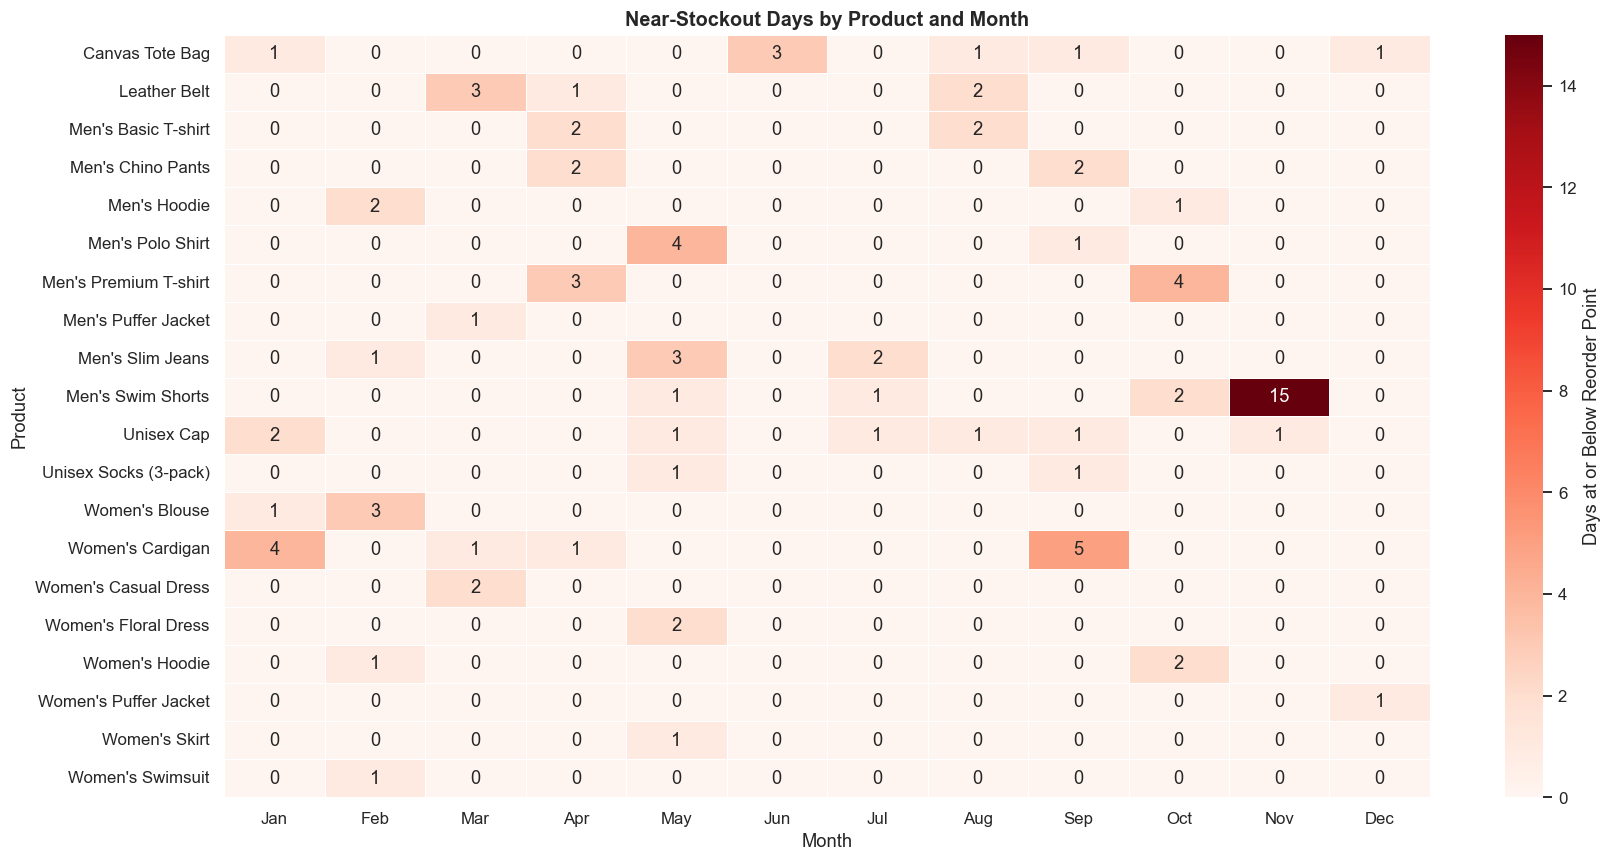

In [28]:
# Heatmap showing how many days each product spent near or below the reorder point,
# broken down by calendar month. Darker red cells show higher stockout risk.
# This chart acts as a reorder calendar: orders should arrive before the red months.
near_stockout['month_num'] = near_stockout['date'].dt.month

heatmap_data  = near_stockout.groupby(['product_name', 'month_num']).size().reset_index(name='days_at_risk')
heatmap_pivot = heatmap_data.pivot(index='product_name', columns='month_num', values='days_at_risk').fillna(0)

# Replace numeric month columns with readable names
month_labels = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
heatmap_pivot.columns = [month_labels.get(c, c) for c in heatmap_pivot.columns]

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Days at or Below Reorder Point'})
plt.title("Near-Stockout Days by Product and Month", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [29]:
# Stockout risk summarised at the category level.
# days_per_product shows the average stockout exposure per product in each category.
category_stockout = near_stockout.groupby('category').agg(
    near_stockout_days = ('date',         'count'),
    products_affected  = ('product_name', 'nunique')
).reset_index()

category_stockout['days_per_product'] = (category_stockout['near_stockout_days'] / category_stockout['products_affected']).round(1)
category_stockout = category_stockout.sort_values('near_stockout_days', ascending=False)

print("Stockout Risk by Category:")
print(category_stockout.to_string(index=False))

Stockout Risk by Category:
category  near_stockout_days  products_affected  days_per_product
     Men                  49                  8               6.1
   Women                  25                  8               3.1
     All                  22                  4               5.5


**Finding:** Products with the highest near-stockout days need larger safety stock buffers
or more frequent reorder cycles. The heatmap identifies the exact months each product is
most at risk, which allows the buying team to schedule deliveries to arrive before those
months. Products showing fewer than 21 days in avg_days_to_stockout during peak risk months
need a reorder placed right away. High-risk categories should be prioritized in the
annual procurement plan. Comparing this heatmap against the revenue data for those same
products and months can confirm whether stockouts are causing lost sales.

##  What Is Our True Profit After All Costs?
**Analysis type: Descriptive + Prescriptive** (What happened? + What to do?)

The business problem states that profit margins are unclear because operating costs
(rent, payroll, marketing, etc.) eat into revenue. The sales data captures gross and net
profit at the transaction level but does not include operating expenses. True operating
profit subtracts all business expenses from the net profit generated by sales.

The is_fixed_cost flag from feature engineering separates fixed costs (Rent, Insurance,
Software) from variable costs (COGS, Marketing, Payroll, Utilities). This distinction
matters because fixed costs must be paid regardless of revenue, while variable costs
can in theory be reduced if sales volumes fall.

In [30]:
# Total 18-month profit picture.
# net_profit from sales already accounts for COGS and returns at the transaction level.
# We then subtract all operating expenses to get the true operating profit.
total_net_profit_sales = sales['net_profit'].sum()
total_expenses         = expenses['amount'].sum()
total_fixed            = expenses[expenses['is_fixed_cost'] == True]['amount'].sum()
total_variable         = expenses[expenses['is_fixed_cost'] == False]['amount'].sum()
true_operating_profit  = total_net_profit_sales - total_expenses

print(f"Total Net Profit from Sales (after returns) : ${total_net_profit_sales:>12,.2f}")
print(f"  Fixed Operating Expenses                  : ${total_fixed:>12,.2f}")
print(f"  Variable Operating Expenses               : ${total_variable:>12,.2f}")
print(f"Total Operating Expenses                    : ${total_expenses:>12,.2f}")
print(f"True Operating Profit                       : ${true_operating_profit:>12,.2f}")
print(f"Operating Profit Margin                     : {true_operating_profit / sales['total_sale'].sum() * 100:.1f}%")

Total Net Profit from Sales (after returns) : $  402,839.75
  Fixed Operating Expenses                  : $   72,900.00
  Variable Operating Expenses               : $  474,579.42
Total Operating Expenses                    : $  547,479.42
True Operating Profit                       : $ -144,639.67
Operating Profit Margin                     : -21.5%


In [31]:
# Monthly true profit: net profit from sales minus all operating expenses.
# This shows which months the business is actually profitable after all costs are paid.
monthly_sales_profit = sales.groupby('month')['net_profit'].sum().reset_index()
monthly_sales_profit.columns = ['month', 'net_profit']

monthly_expenses = expenses.groupby('month')['amount'].sum().reset_index()
monthly_expenses.columns = ['month', 'total_expenses']

# Combine into a monthly P&L table
monthly_pnl = monthly_sales_profit.merge(monthly_expenses, on='month', how='inner')
monthly_pnl['true_profit'] = monthly_pnl['net_profit'] - monthly_pnl['total_expenses']
monthly_pnl['month_dt']    = monthly_pnl['month'].dt.to_timestamp()

print("Monthly P&L Summary:")
print(monthly_pnl[['month', 'net_profit', 'total_expenses', 'true_profit']].to_string(index=False))

Monthly P&L Summary:
  month  net_profit  total_expenses  true_profit
2024-01    28985.17        35186.46     -6201.29
2024-02    24669.08        31892.38     -7223.30
2024-03    24755.96        34215.46     -9459.50
2024-04    17164.76        25386.92     -8222.16
2024-05    19374.95        29315.40     -9940.45
2024-06    23073.06        30221.78     -7148.72
2024-07    19007.75        26085.15     -7077.40
2024-08    26106.18        34810.01     -8703.83
2024-09    18165.56        26225.41     -8059.85
2024-10    20440.62        27267.85     -6827.23
2024-11    21518.62        31388.59     -9869.97
2024-12    26594.43        33784.47     -7190.04
2025-01    26619.35        34800.35     -8181.00
2025-02    22951.92        30697.41     -7745.49
2025-03    24757.75        32431.75     -7674.00
2025-04    17525.45        25449.45     -7924.00
2025-05    17936.06        28225.54    -10289.48
2025-06    23193.08        30095.04     -6901.96


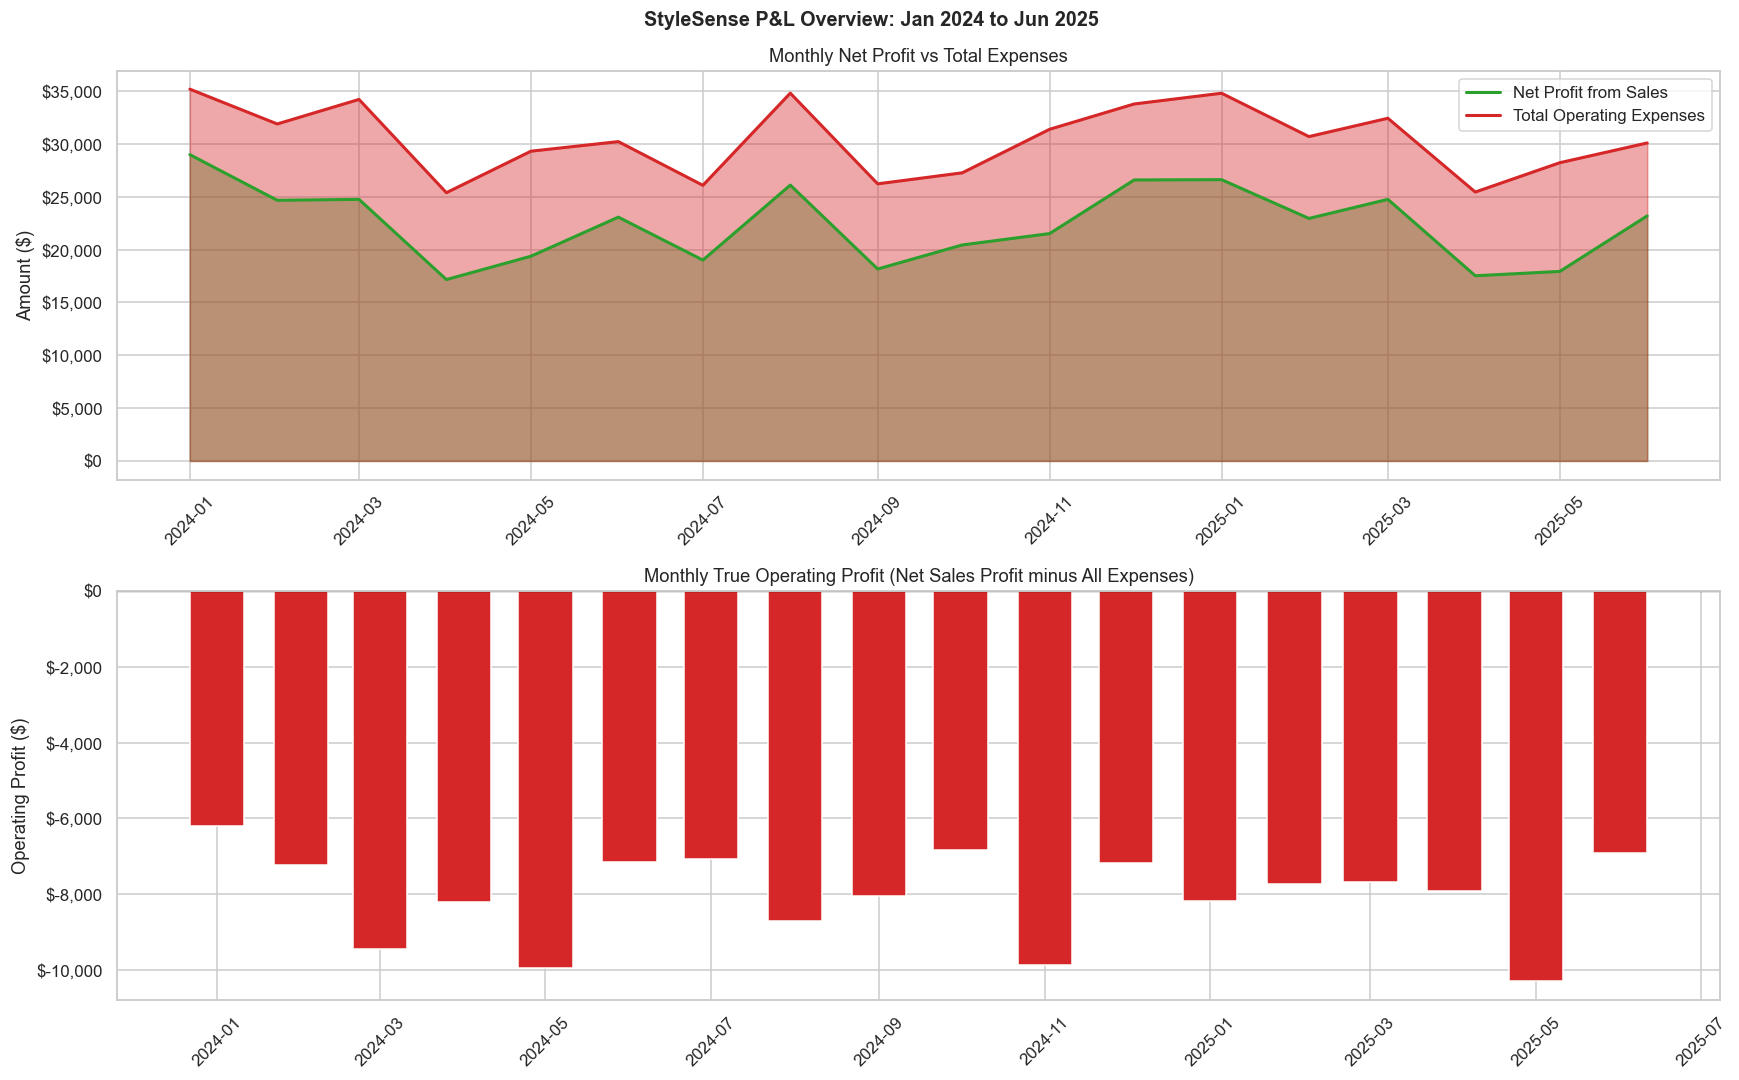

In [32]:
# Two-panel chart showing the full profit picture.
# Top panel: net profit from sales vs total expenses over 18 months.
# Bottom panel: true operating profit per month, green for positive and red for negative.
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top panel: filled area chart of profit vs expenses
axes[0].fill_between(monthly_pnl['month_dt'], monthly_pnl['net_profit'],    alpha=0.4, color=GREEN)
axes[0].fill_between(monthly_pnl['month_dt'], monthly_pnl['total_expenses'], alpha=0.4, color=RED)
axes[0].plot(monthly_pnl['month_dt'], monthly_pnl['net_profit'],    color=GREEN, linewidth=2, label='Net Profit from Sales')
axes[0].plot(monthly_pnl['month_dt'], monthly_pnl['total_expenses'], color=RED,   linewidth=2, label='Total Operating Expenses')
axes[0].set_title("Monthly Net Profit vs Total Expenses")
axes[0].set_ylabel("Amount ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bottom panel: true operating profit bar chart, coloured green if positive and red if negative
bar_colors = [GREEN if v >= 0 else RED for v in monthly_pnl['true_profit']]
axes[1].bar(monthly_pnl['month_dt'], monthly_pnl['true_profit'], color=bar_colors, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Monthly True Operating Profit (Net Sales Profit minus All Expenses)")
axes[1].set_ylabel("Operating Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("StyleSense P&L Overview: Jan 2024 to Jun 2025", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Expense Breakdown:
                category cost_type    amount  pct
      Cost of Goods Sold  Variable 249989.00 45.7
                 Payroll  Variable 187300.32 34.2
                    Rent     Fixed  63000.00 11.5
    Shipping & Packaging  Variable  15870.57  2.9
               Marketing  Variable  15064.49  2.8
               Insurance     Fixed   7200.00  1.3
               Utilities  Variable   6355.04  1.2
Software & Subscriptions     Fixed   2700.00  0.5


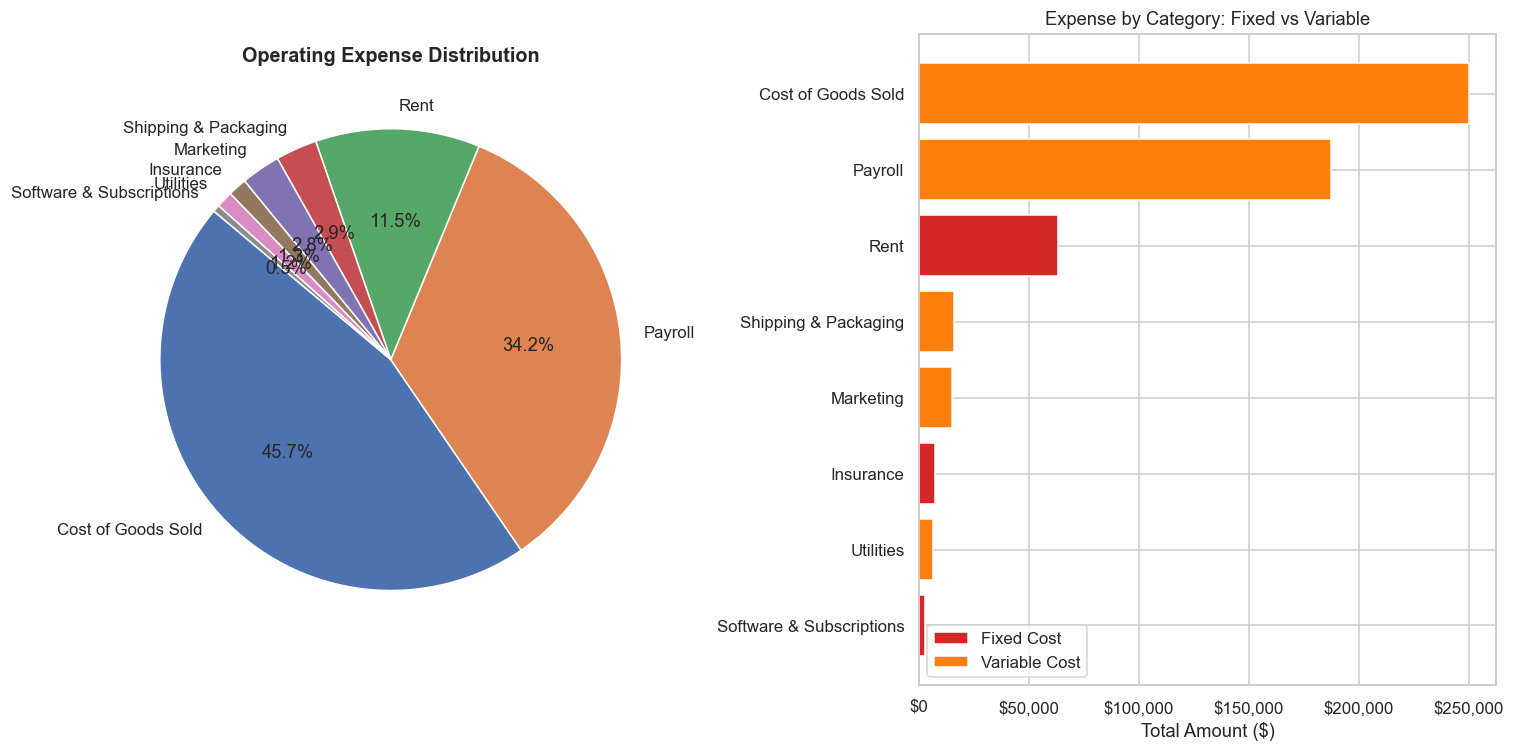

In [33]:
# Expense breakdown showing how much was spent in each category
# and whether that category is a fixed or variable cost.
expense_breakdown = expenses.groupby(['category', 'is_fixed_cost'])['amount'].sum().reset_index()
expense_breakdown = expense_breakdown.sort_values('amount', ascending=False)
expense_breakdown['pct']       = (expense_breakdown['amount'] / expense_breakdown['amount'].sum() * 100).round(1)
expense_breakdown['cost_type'] = expense_breakdown['is_fixed_cost'].map({True: 'Fixed', False: 'Variable'})

print("Expense Breakdown:")
print(expense_breakdown[['category', 'cost_type', 'amount', 'pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left chart: pie chart showing the share of each expense category
axes[0].pie(expense_breakdown['amount'], labels=expense_breakdown['category'],
            autopct='%1.1f%%', startangle=140)
axes[0].set_title("Operating Expense Distribution", fontsize=13, fontweight='bold')

# Right chart: horizontal bar chart coloured red for fixed and orange for variable
bar_colors = [RED if f else ORANGE for f in expense_breakdown['is_fixed_cost']]
axes[1].barh(expense_breakdown['category'][::-1], expense_breakdown['amount'][::-1],
             color=bar_colors[::-1])
axes[1].set_title("Expense by Category: Fixed vs Variable")
axes[1].set_xlabel("Total Amount ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
legend_elements = [mpatches.Patch(facecolor=RED,    label='Fixed Cost'),
                   mpatches.Patch(facecolor=ORANGE, label='Variable Cost')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

**Finding:** Months where true operating profit is negative are loss months where the
business is spending more than it earns after all costs. Fixed costs such as Rent,
Insurance, and Software are unavoidable regardless of revenue. In low-revenue months
they form a floor that must be covered before the business breaks even. Variable costs
such as COGS, Marketing, and Payroll are more flexible and scale with activity.
If COGS is the largest expense category, StyleSense should explore renegotiating
supplier pricing or increasing order volumes to reduce the cost per unit. If loss months
are driven by fixed costs being too high relative to revenue, the response is to grow
sales volume rather than cut overhead.


## **Key actions for management:**
1. Tighten discount caps on products with the highest margin erosion (Q1, Q3).
2. Launch a personalised win-back campaign targeting the At Risk customers listed in Q2.
3. Shift marketing budget toward channels and months with the highest Profit ROMS (Q5).
4. Place seasonal restock orders 4 to 6 weeks before peak near-stockout months (Q6, Q7).
5. In loss months, focus on driving sales volume rather than cutting fixed overhead (Q8).